# Titanic Data Analysis

## Project Overview

This project analyzes the Titanic dataset using Python, NumPy, Pandas, and Matplotlib to understand factors related to passenger survival.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###Upload Dataset File

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


###Find dataset Size

In [ ]:
df.shape

(891, 12)

###Display Columns

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

###Check Data Types

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Data Cleaning

Before performing analysis, we will check the dataset for missing values and duplicate rows. We will then handle the missing values appropriately while keeping the Cabin column for additional analysis.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


###Calculate Missing Percentages

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


### Handling Missing Age Values

There were 177 missing values in the Age column, representing approximately 19.87% of the dataset. The missing values were replaced with the median age of 28 years. The median was used because it is less affected by extreme age values and allows us to retain all passenger records for analysis.

In [ ]:
df['Age'].median()

28.0

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
df['Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [ ]:
df['Age'].isnull().sum()

np.int64(0)

### Handling Missing Embarked Values

There were 2 missing values in the Embarked column, representing approximately 0.22% of the dataset. Since Embarked is a categorical column, the missing values were replaced with the mode. The most frequently occurring embarkation port was S, so the missing values were filled with S.

In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
df['Embarked'].mode()

,Embarked
0,S


In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df['Embarked'].isnull().sum()

np.int64(0)

### Checking for Duplicate Rows

We will check whether the dataset contains any completely duplicated rows. Duplicate records could affect the accuracy of our analysis, so they should be identified before proceeding.

In [ ]:
df.duplicated().sum()

np.int64(0)

### Handling the Cabin Column

The Cabin column contains a large number of missing values. Since approximately 77.10% of the Cabin values are missing and Cabin is not required for the main analysis questions, the column was removed from the dataset. This avoids using a highly incomplete variable in the analysis.

In [ ]:
df = df.drop(columns=['Cabin'])

In [ ]:
df = df.drop(columns=['Cabin'], errors='ignore')

## 3. Data Analysis

### 3.1 Number of Passengers
Question # 1

How many passengers were on the Titanic?

In [ ]:
len(df)

891

### 3.2 Number of Male and Female Passengers
Question 2 — Male and Female Passengers

In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


###3.3 Number of Survived Passengers
Question 3 — How Many Passengers Survived?

In [ ]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


### 3.4 Survival Percentage
Question 4 — What Percentage of Passengers Survived?


In [ ]:
survival_percentage = (df['Survived'].sum() / len(df)) * 100

survival_percentage

np.float64(38.38383838383838)

### 3.5 Average Age of Passengers

Question 5 — What Was the Average Age of the Passengers?

In [ ]:
average_age = df['Age'].mean()

average_age

np.float64(29.36158249158249)

### 3.6 Average Fare Paid

Question 6 — What Was the Average Fare Paid by Passengers?

In [ ]:
average_fare = df['Fare'].mean()

average_fare

np.float64(32.204207968574636)

### 3.7 Most Common Passenger Class

Question 7 — What Was the Most Common Passenger Class?

In [ ]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


### 3.8 Survival Rate by Passenger Class

Question 8 — What Was the Survival Rate for Each Passenger Class?

In [ ]:
survival_rate_by_class = df.groupby('Pclass')['Survived'].mean() * 100

survival_rate_by_class

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


### 3.9 Survival Rate by Gender

Question 9 — What Was the Survival Rate for Each Gender?

In [ ]:
survival_rate_by_gender = df.groupby('Sex')['Survived'].mean() * 100

survival_rate_by_gender

,Survived
Sex,
female,74.203822
male,18.890815


### 3.10 Gender with the Higher Survival Rate

Question 10 — Which Gender Had the Higher Survival Rate?

Based on the calculated survival rates, female passengers had the higher survival rate at approximately 74.20%, compared with 18.89% for male passengers.

## 4. Create New Columns

In this section, we will create two new columns, FamilySize and AgeGroup. These columns will help us investigate whether family size and passenger age were related to survival.

### 4.1 Creating FamilySize

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


4.2 Creating AgeGroup

To make age-based analysis easier, we will create an AgeGroup column by grouping passengers into different age categories. This will allow us to investigate whether passenger age group was related to survival.

In [ ]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 19, 59, 100],
    labels=['Child', 'Teenager', 'Adult', 'Senior']
)

df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


4.3 Number of Passengers in Each Age Group

We will count the number of passengers in each age group to understand how the passengers were distributed across the different age categories.

In [ ]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
Adult,701
Teenager,95
Child,69
Senior,26


4.4 Does Family Size Affect Survival?

To investigate whether family size was related to survival, we will calculate the survival rate for each family size. The survival rate is calculated as the mean of the Survived column for each FamilySize.

In [ ]:
survival_rate_by_family = df.groupby('FamilySize')['Survived'].mean() * 100

survival_rate_by_family

,Survived
FamilySize,
1,30.353818
2,55.279503
3,57.843137
4,72.413793
5,20.000000
6,13.636364
7,33.333333
8,0.000000
11,0.000000


4.5 Does Age Group Affect Survival?

To investigate whether age group was related to survival, we will calculate the survival rate for each AgeGroup. This allows us to compare survival percentages between children, teenagers, adults, and seniors

In [ ]:
survival_rate_by_age_group = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

survival_rate_by_age_group

,Survived
AgeGroup,
Child,57.971014
Teenager,41.052632
Adult,36.519258
Senior,26.923077


In [ ]:
age_group_analysis = df.groupby('AgeGroup', observed=True).agg(
    Passengers=('PassengerId', 'count'),
    SurvivalRate=('Survived', 'mean')
)

age_group_analysis['SurvivalRate'] = age_group_analysis['SurvivalRate'] * 100

age_group_analysis

,Passengers,SurvivalRate
AgeGroup,,
Child,69,57.971014
Teenager,95,41.052632
Adult,701,36.519258
Senior,26,26.923077


# 5. Data Visualization

In this section, we will create visualizations to better understand the Titanic passenger data and survival patterns. The charts will focus on passenger gender, survival status, passenger class, gender survival rates, and age groups.

## 5.1 Number of Male and Female Passengers

This chart shows the number of male and female passengers in the dataset.

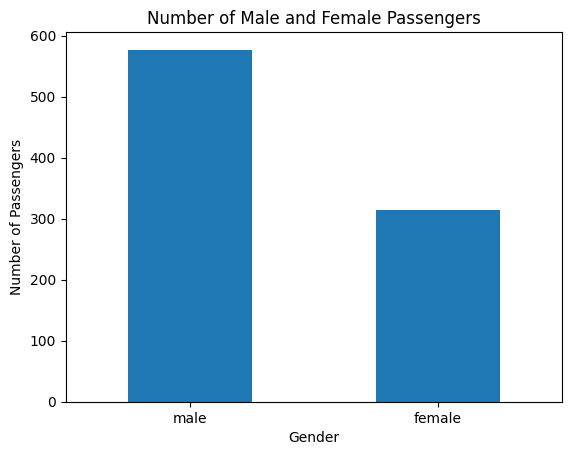

In [ ]:
df['Sex'].value_counts().plot(kind='bar')

plt.title('Number of Male and Female Passengers')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.show()

### Observation

The dataset contains more male passengers than female passengers. There were 577 male passengers and 314 female passengers.

## 5.2 Number of Survived and Non-Survived Passengers

This chart shows the number of passengers who survived and those who did not survive.

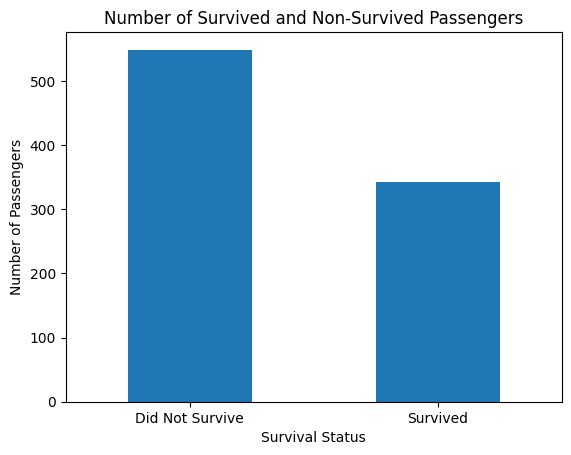

In [ ]:
df['Survived'].value_counts().plot(kind='bar')

plt.title('Number of Survived and Non-Survived Passengers')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'], rotation=0)
plt.show()

### Observation

The chart shows that more passengers did not survive than survived. A total of 549 passengers did not survive, while 342 passengers survived.

## 5.3 Survival Rate by Passenger Class

This chart shows the percentage of passengers who survived in each passenger class.

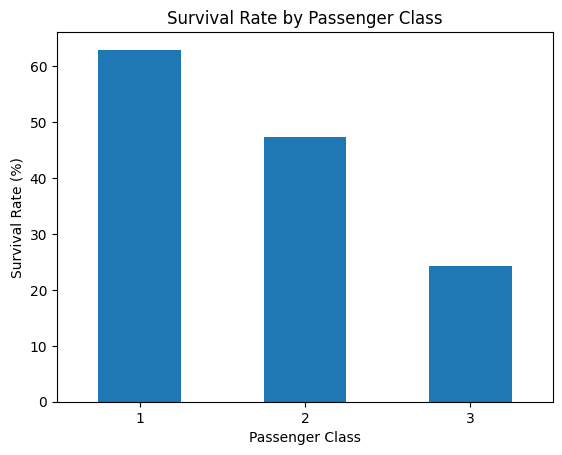

In [ ]:
survival_rate_by_class = df.groupby('Pclass')['Survived'].mean() * 100

survival_rate_by_class.plot(kind='bar')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Observation

The survival rate was highest among first-class passengers at approximately 62.96%. Second-class passengers had a survival rate of approximately 47.28%, while third-class passengers had the lowest survival rate at approximately 24.24%. This shows a clear difference in survival rates across passenger classes.

## 5.4 Survival Rate by Gender

This chart shows the percentage of male and female passengers who survived.

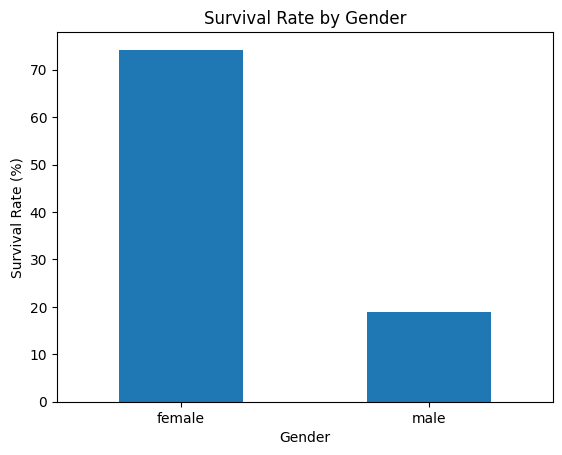

In [50]:
 survival_rate_by_gender = df.groupby('Sex')['Survived'].mean() * 100

survival_rate_by_gender.plot(kind='bar')

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Observation

Female passengers had a substantially higher survival rate than male passengers. Approximately 74.20% of female passengers survived, compared with approximately 18.89% of male passengers.

# 6. Final Findings

Based on the analysis and visualizations, the following important findings were identified:

1. The dataset contains a total of 891 passengers.

2. There were more male passengers than female passengers. The dataset contained 577 male passengers and 314 female passengers.

3. Out of 891 passengers, 342 survived and 549 did not survive. The overall survival rate was approximately 38.38%.

4. The average age of the passengers was approximately 29.36 years.

5. The average fare paid by passengers was approximately 32.20.

6. Passenger Class 3 was the most common passenger class, with 491 passengers. Class 1 had 216 passengers, while Class 2 had 184 passengers.

7. Passenger Class 1 had the highest survival rate at approximately 62.96%. Class 2 had a survival rate of approximately 47.28%, while Class 3 had the lowest survival rate at approximately 24.24%.

8. Female passengers had a substantially higher survival rate than male passengers. Approximately 74.20% of female passengers survived, compared with approximately 18.89% of male passengers.

Overall, the analysis shows that passenger class and gender were strongly associated with survival in this dataset. First-class passengers had the highest survival rate, while female passengers had a much higher survival rate than male passengers.